In [67]:
import jax
import jax.numpy as jnp
import jaxls
import numpy as onp

In [78]:
# Dynamics / observation definitions.
m = 1.0
dt = 0.1

A = jnp.block([[jnp.eye(3), dt * jnp.eye(3)], [jnp.zeros((3, 3)), jnp.eye(3)]])
B = jnp.concatenate([jnp.zeros((3, 3)), (dt / m) * jnp.eye(3)], axis=0)

C_pos = jnp.concatenate([jnp.eye(3), jnp.zeros((3, 3))], axis=1)
C_vel = jnp.concatenate([jnp.zeros((3, 3)), jnp.eye(3)], axis=1)

Q = dt * 0.25 * jnp.eye(6)
R = dt * 2.0 * jnp.eye(3)

def f(x, u):
    return A @ x + B @ u

def h(x):
    return C_vel @ x

# Simulate trajectory
horizon = 100
scale= 3.0

t = jnp.linspace(0, 2 * jnp.pi, horizon + 1)

# Lemniscate: x = sin(t), y = sin(2t)/2, z = 0
pos_ref = scale * jnp.stack([
    jnp.sin(t),
    jnp.sin(2 * t) / 2,
    jnp.ones_like(t),
], axis=1)

# Finite-difference velocities
vel_ref = jnp.diff(pos_ref, axis=0) / dt
vel_ref = jnp.concatenate([vel_ref, vel_ref[-1:]], axis=0)  # repeat last

X_ref = jnp.concatenate([pos_ref, vel_ref], axis=1)


# Initial state
mu0 = X_ref[0]
Sigma0 = 2.0 * jnp.eye(6) 
x0 = jax.random.multivariate_normal(jax.random.PRNGKey(0), mu0, Sigma0)

# Simulate with noise
key = jax.random.PRNGKey(42)
k1, k2, k3 = jax.random.split(key, 3)
W = jax.random.multivariate_normal(k1, jnp.zeros(6), Q, (horizon,))
V = jax.random.multivariate_normal(k2, jnp.zeros(3), R, (horizon,))

X = jnp.zeros((horizon + 1, 6))
Y = jnp.zeros((horizon + 1, 3))

# PD gains
Kp = 10.0 * jnp.eye(3)
Kd = 5.0 * jnp.eye(3)

# Simulate with PD tracking
x = x0
X = X.at[0].set(x)
Y = Y.at[0].set(jnp.inf * jnp.ones(3))
U = jnp.zeros((horizon, 3))

for t_idx in range(horizon):
    pos = x[:3]
    vel = x[3:]
    pos_des = pos_ref[t_idx + 1]
    vel_des = vel_ref[t_idx + 1]

    u = Kp @ (pos_des - pos) + Kd @ (vel_des - vel)
    U = U.at[t_idx].set(u)

    x = f(x, u) + W[t_idx]
    y = h(x) + V[t_idx]

    X = X.at[t_idx + 1].set(x)
    Y = Y.at[t_idx + 1].set(y)

In [ ]:
# Build the least-squares problem.
def res_prior(x: jnp.ndarray) -> jnp.ndarray:
    return jax.scipy.linalg.solve(jax.scipy.linalg.cholesky(Sigma0), x - mu0)

def res_dynamics(x_prev: jnp.ndarray, x: jnp.ndarray, u: jnp.ndarray) -> jnp.ndarray:
    return jax.scipy.linalg.solve(jax.scipy.linalg.cholesky(Q), x - f(x_prev, u))

def res_observation(x: jnp.ndarray, y: jnp.ndarray) -> jnp.ndarray:
    return jax.scipy.linalg.solve(jax.scipy.linalg.cholesky(R), h(x) - y)

def build_residuals(X: jnp.ndarray, U: jnp.ndarray, Y: jnp.ndarray) -> jnp.ndarray:
    res = []
    res.append(res_prior(X[0]))
    for t_idx in range(horizon):
        res.append(res_dynamics(X[t_idx], X[t_idx + 1], U[t_idx]))
        res.append(res_observation(X[t_idx + 1], Y[t_idx + 1]))
    return jnp.concatenate(res, axis=0)

residuals = build_residuals(X, U, Y)
jacobian = jax.jacobian(build_residuals, argnums=(0))(X, U, Y)

0.0032894017878609054


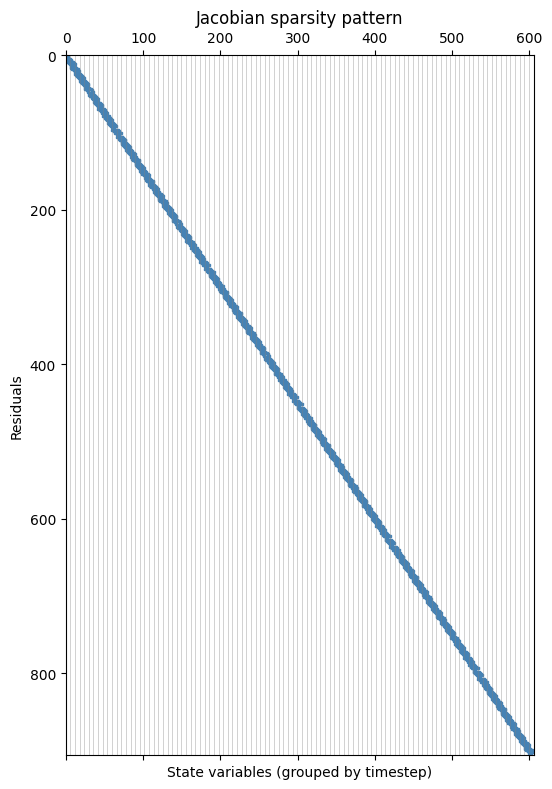

In [74]:
import matplotlib.pyplot as plt

# Compute Jacobian of residuals w.r.t. X only (fixing U, Y)
# jacobian returns shape (len_residuals, T+1, n) — need to reshape
jac_fn = jax.jacobian(lambda X: build_residuals(X, U, Y))
J_raw = jac_fn(X)  # shape: (n_res, T+1, n_x)

# Reshape to 2D: (n_residuals, (T+1)*n_x)
n_res = J_raw.shape[0]
J = onp.array(J_raw).reshape(n_res, -1)

# Spy plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.spy(onp.abs(J) > 1e-10, markersize=2, color='steelblue')

print(onp.mean(onp.abs(J) > 1e-10))  # count nonzeros per column

# Label the column blocks (each block = one timestep's states)
n_x = X.shape[1]
T = U.shape[0]
for t in range(T + 1):
    ax.axvline(x=t * n_x - 0.5, color='gray', linewidth=0.5, alpha=0.5)

ax.set_xlabel("State variables (grouped by timestep)")
ax.set_ylabel("Residuals")
ax.set_title("Jacobian sparsity pattern")
plt.tight_layout()
plt.show()

In [79]:
class StateVar(jaxls.Var[jax.Array], default_factory=lambda: jnp.zeros(6)):
    """Drone state variable, consisting of position and velocity."""

drone_state_vars = StateVar(id=jnp.arange(horizon+1))

@jaxls.Cost.factory
def dynamics_cost(
    vals: jaxls.VarValues,
    state_curr: StateVar,
    state_next: StateVar,
    u: jax.Array,
) -> jax.Array:
    """Cost enforcing the dynamics constraint between consecutive states."""
    x_curr = vals[state_curr]
    x_next = vals[state_next]

    # Dynamics residual weighted by process noise covariance sqrt.
    return jnp.real(jax.scipy.linalg.sqrtm(jnp.linalg.inv(Q))) @ (x_next - f(x_curr, u))

@jaxls.Cost.factory
def measurement_cost(
    vals: jaxls.VarValues,
    state: StateVar,
    y: jax.Array,
) -> jax.Array:
    """Cost enforcing the measurement constraint between state and observation."""
    x = vals[state]

    # Measurement residual weighted by measurement noise covariance sqrt.
    return jnp.real(jax.scipy.linalg.sqrtm(jnp.linalg.inv(R))) @ (h(x) - y)

@jaxls.Cost.factory
def prior_cost(
    vals: jaxls.VarValues,
    state: StateVar,
    mean: jax.Array = mu0,
    cov: jax.Array = Sigma0,
) -> jax.Array:
    """Cost enforcing the prior constraint on the initial state."""
    x = vals[state]

    # Prior residual weighted by prior covariance sqrt.
    return jnp.real(jax.scipy.linalg.sqrtm(jnp.linalg.inv(Sigma0))) @ (x - mu0)

costs: list[jaxls.Cost] = [
    prior_cost(StateVar(id=0), mu0, Sigma0),
    dynamics_cost(StateVar(id=jnp.arange(horizon)), StateVar(id=jnp.arange(1, horizon+1)), u=U),
    measurement_cost(StateVar(id=jnp.arange(1, horizon+1)), Y[1:]),
]

initial_guess = jaxls.VarValues.make([drone_state_vars.with_value(0.1 + jnp.tile(mu0, (horizon+1,1)))])
problem = jaxls.LeastSquaresProblem(costs, [drone_state_vars])
problem = problem.analyze()

solution = problem.solve(initial_guess)
cov = problem.make_covariance_estimator(solution)
covariance_jit = jax.jit(cov.covariance)
X_smooth = onp.array(jnp.stack([solution[StateVar(id=t)] for t in range(horizon + 1)]))

2026-03-26 09:56:13.133 | INFO     | jaxls._py310._problem:analyze:121 - Building optimization problem with 201 terms and 101 variables: 201 costs, 0 eq_zero, 0 leq_zero, 0 geq_zero
2026-03-26 09:56:13.152 | INFO     | jaxls._py310._problem:analyze:229 - Vectorizing group with 1 costs, 1 variables each: prior_cost
2026-03-26 09:56:13.182 | INFO     | jaxls._py310._problem:analyze:229 - Vectorizing group with 100 costs, 2 variables each: dynamics_cost
2026-03-26 09:56:13.204 | INFO     | jaxls._py310._problem:analyze:229 - Vectorizing group with 100 costs, 1 variables each: measurement_cost
2026-03-26 09:56:14.079 | INFO     | jaxls._py310.utils:_log:23 -  step #0: cost=10716.8965 lambd=0.0005 inexact_tol=1.0e-02
2026-03-26 09:56:14.080 | INFO     | jaxls._py310.utils:_log:23 -      - prior_cost(1):  0.03000 (avg 0.00500)
2026-03-26 09:56:14.081 | INFO     | jaxls._py310.utils:_log:23 -      - dynamics_cost(100): 1834.55615 (avg 3.05759)
2026-03-26 09:56:14.081 | INFO     | jaxls._py310

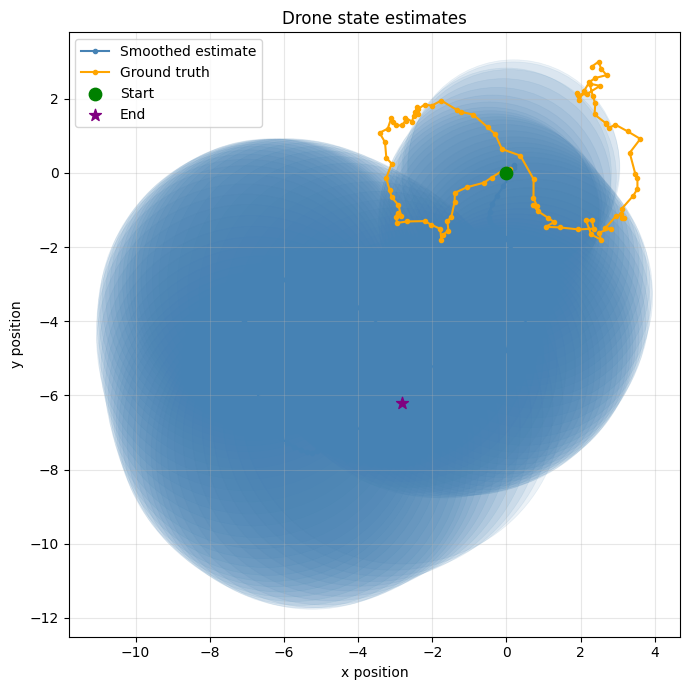

In [81]:
import numpy as onp
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Ellipse

def cov_ellipse(mean_xy, cov_xy, n_std=2.0, **kwargs):
    """Return a matplotlib Ellipse patch for a 2D Gaussian."""
    eigvals, eigvecs = onp.linalg.eigh(cov_xy)
    # Clamp negative eigenvalues from numerical noise
    eigvals = onp.maximum(eigvals, 0)
    angle = onp.degrees(onp.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * n_std * onp.sqrt(eigvals)
    return Ellipse(xy=mean_xy, width=width, height=height, angle=angle, **kwargs)

# --- Extract marginal x-y covariances at each timestep ---
# State layout: [px, py, pz, vx, vy, vz] — adjust slice if yours differs
POS_IDX = [0, 1]  # x-y position indices

covs_xy = []
for t in range(horizon + 1):
    state_var_t = StateVar(id=t)
    # Full 6x6 covariance for this state variable
    C = onp.array(covariance_jit(state_var_t, state_var_t))
    # Marginal 2x2 for x-y
    C_xy = C[onp.ix_(POS_IDX, POS_IDX)]
    covs_xy.append(C_xy)

# --- Extract ground truth and estimated trajectory ---
X_smooth_xy = X_smooth[:, POS_IDX]   # (T+1, 2) estimated positions
Y_xy = Y[1:, :]                       # observations — adjust if your h() maps differently

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 7))

# Draw covariance ellipses (faded, behind trajectory)
for t, (mean, C_xy) in enumerate(zip(X_smooth_xy, covs_xy)):
    alpha = 0.1
    ell = cov_ellipse(
        mean, C_xy, n_std=2,
        facecolor='steelblue', edgecolor='steelblue',
        alpha=alpha, linewidth=0.5
    )
    ax.add_patch(ell)

# Estimated trajectory
ax.plot(X_smooth_xy[:, 0], X_smooth_xy[:, 1],
        'o-', color='steelblue', markersize=3, linewidth=1.5,
        label='Smoothed estimate', zorder=3)

# Ground truth trajectory
ax.plot(X[:, 0], X[:, 1],
        'o-', color='orange', markersize=3, linewidth=1.5,
        label='Ground truth', zorder=4)

# Start / end markers
ax.scatter(*X_smooth_xy[0],  s=80, color='green',  zorder=5, label='Start')
ax.scatter(*X_smooth_xy[-1], s=80, color='purple', zorder=5, marker='*', label='End')

ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax.set_title('Drone state estimates')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

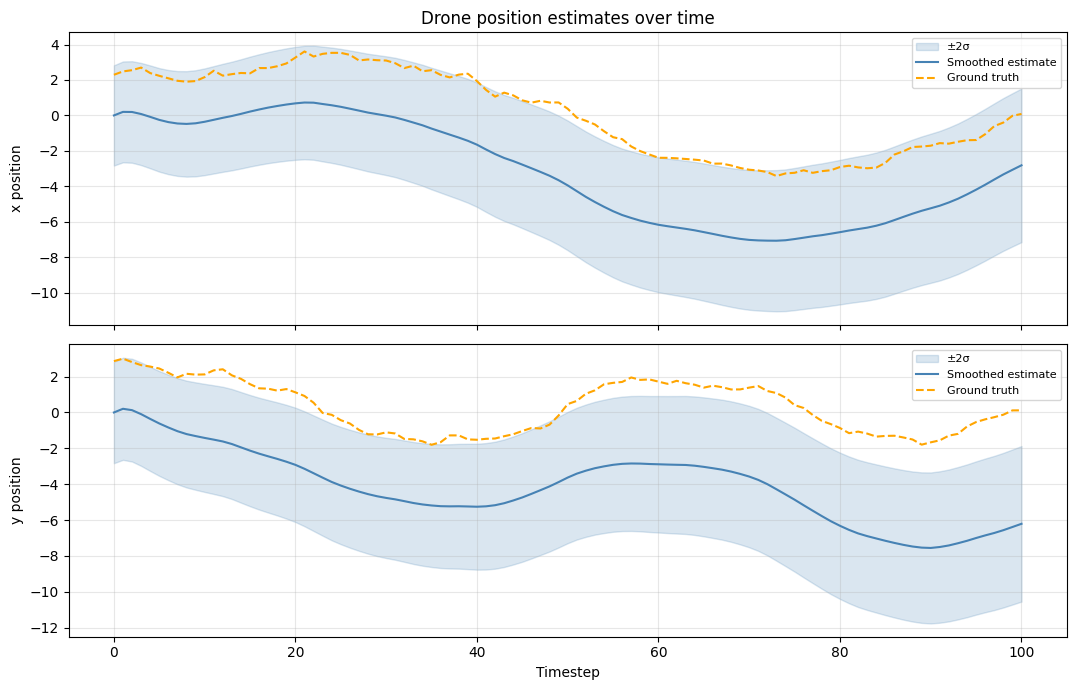

In [82]:
# --- Extract per-timestep marginal stds from the diagonal of covs_xy ---
stds = onp.array([onp.sqrt(onp.maximum(onp.diag(C), 0)) for C in covs_xy])
# stds shape: (T+1, 2) — columns are [std_x, std_y]

ts = onp.arange(horizon + 1)
x_est, y_est = X_smooth[:, 0], X_smooth[:, 1]
x_gt,  y_gt  = X[:, 0],        X[:, 1]
std_x, std_y = stds[:, 0],     stds[:, 1]

fig, (ax_x, ax_y) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for ax, est, gt, std, label in [
    (ax_x, x_est, x_gt, std_x, 'x'),
    (ax_y, y_est, y_gt, std_y, 'y'),
]:
    # 2-sigma shaded band
    ax.fill_between(ts,
                    est - 2 * std,
                    est + 2 * std,
                    color='steelblue', alpha=0.2, label='±2σ')

    # Smoothed estimate
    ax.plot(ts, est, color='steelblue', linewidth=1.5, label='Smoothed estimate')
    # Ground truth
    ax.plot(ts, gt, color='orange', linewidth=1.5, linestyle='--', label='Ground truth')

    ax.set_ylabel(f'{label} position')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

ax_x.set_title('Drone position estimates over time')
ax_y.set_xlabel('Timestep')
plt.tight_layout()
plt.show()